В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [73]:
import os
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
    f1_score
)

DATA_DIR = "data"
ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

raw_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))

train_df, val_df = train_test_split(
    raw_df,
    test_size=0.2,
    random_state=42,
    stratify=raw_df["Exited"]
)

print(train_df.shape)
print(val_df.shape)
display(raw_df.head())

(12000, 14)
(3000, 14)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [74]:
target_col = "Exited"

# id, CustomerId та Surname не використовуємо як предиктори:
# - id є технічним ідентифікатором рядка;
# - CustomerId є ідентифікатором клієнта;
# - Surname також є своєрідним ідентифікатором клієнта.
drop_cols = ["id", "CustomerId", "Surname", target_col]
input_cols = [col for col in train_df.columns if col not in drop_cols]

train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

print("Input columns:", input_cols)
print("Target column:", target_col)
display(train_inputs.head())
display(train_targets.head())

Input columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Target column: Exited


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
7180,682.0,France,Male,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24
10393,684.0,France,Female,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31
80,705.0,Germany,Male,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01
3365,669.0,Spain,Male,58.0,0.0,0.00,2.0,0.0,1.0,51565.98
12236,707.0,France,Male,21.0,3.0,0.00,2.0,1.0,1.0,148564.76


7180     0.0
10393    0.0
80       0.0
3365     0.0
12236    0.0
Name: Exited, dtype: float64

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [75]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Categorical columns: ['Geography', 'Gender']


4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [76]:
# Передобробка:
# 1. Пропущені значення у числових колонках заповнюємо медіаною з train,
#    бо медіана стійкіша до викидів, ніж середнє.
# 2. Пропущені значення у категоріальних колонках заповнюємо найчастішим
#    значенням з train, бо це природний базовий варіант для категорій.
# 3. Числові ознаки масштабуємо MinMaxScaler, щоб логістична регресія
#    працювала стабільніше з ознаками різного масштабу.
# 4. Категоріальні ознаки кодуємо OneHotEncoder, щоб модель могла
#    використовувати текстові категорії як числові ознаки.

numeric_medians = train_inputs[numeric_cols].median()
train_inputs[numeric_cols] = train_inputs[numeric_cols].fillna(numeric_medians)
val_inputs[numeric_cols] = val_inputs[numeric_cols].fillna(numeric_medians)

categorical_modes = {}
for col in categorical_cols:
    mode_value = train_inputs[col].mode(dropna=True)[0]
    categorical_modes[col] = mode_value
    train_inputs[col] = train_inputs[col].fillna(mode_value)
    val_inputs[col] = val_inputs[col].fillna(mode_value)

scaler = MinMaxScaler()
train_inputs[numeric_cols] = scaler.fit_transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder.fit(train_inputs[categorical_cols])

encoded_cols = encoder.get_feature_names_out(categorical_cols).tolist()

train_encoded = pd.DataFrame(
    encoder.transform(train_inputs[categorical_cols]),
    columns=encoded_cols,
    index=train_inputs.index
)

val_encoded = pd.DataFrame(
    encoder.transform(val_inputs[categorical_cols]),
    columns=encoded_cols,
    index=val_inputs.index
)

train_inputs = pd.concat(
    [train_inputs.drop(columns=categorical_cols), train_encoded],
    axis=1
)

val_inputs = pd.concat(
    [val_inputs.drop(columns=categorical_cols), val_encoded],
    axis=1
)

model_cols = numeric_cols + encoded_cols

display(train_inputs.head())
display(val_inputs.head())

print("Train inputs shape:", train_inputs.shape)
print("Validation inputs shape:", val_inputs.shape)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
7180,0.599045,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772,1.0,0.0,0.0,0.0,1.0
10393,0.603819,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603,1.0,0.0,0.0,1.0,0.0
80,0.653938,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180,0.0,1.0,0.0,0.0,1.0
3365,0.568019,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797,0.0,0.0,1.0,0.0,1.0
12236,0.658711,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837,1.0,0.0,0.0,0.0,1.0


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
6490,0.675418,0.500000,0.1,0.551870,1.000000,1.0,1.0,0.364704,0.0,1.0,0.0,0.0,1.0
3646,0.386635,0.410714,0.5,0.000000,0.333333,1.0,1.0,0.190942,1.0,0.0,0.0,0.0,1.0
5306,0.715990,0.357143,0.2,0.000000,0.333333,0.0,1.0,0.584853,1.0,0.0,0.0,1.0,0.0
652,0.577566,0.446429,0.4,0.742441,0.000000,0.0,1.0,0.558109,1.0,0.0,0.0,1.0,0.0
2627,0.589499,0.214286,0.4,0.000000,0.333333,1.0,0.0,0.718420,0.0,0.0,1.0,1.0,0.0


Train inputs shape: (12000, 13)
Validation inputs shape: (3000, 13)


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [77]:
# Зберігаємо підготовлені дані.
# Якщо у середовищі є parquet engine, буде створено parquet.
# Якщо parquet engine недоступний, додатково збережемо pickle-копії,
# щоб ноутбук виконувався без помилок.

prepared_data_dir = os.path.join(ARTIFACTS_DIR, "prepared_data")
os.makedirs(prepared_data_dir, exist_ok=True)

datasets_to_save = {
    "train_inputs": train_inputs,
    "train_targets": train_targets.to_frame(name=target_col),
    "val_inputs": val_inputs,
    "val_targets": val_targets.to_frame(name=target_col)
}

saved_files = []

for name, df_to_save in datasets_to_save.items():
    parquet_path = os.path.join(prepared_data_dir, f"{name}.parquet")
    pickle_path = os.path.join(prepared_data_dir, f"{name}.pkl")

    try:
        df_to_save.to_parquet(parquet_path, index=False)
        saved_files.append(os.path.basename(parquet_path))
    except ImportError:
        df_to_save.to_pickle(pickle_path)
        saved_files.append(os.path.basename(pickle_path))

print("Saved files:")
print(os.listdir(prepared_data_dir))

Saved files:
['val_inputs.pkl', 'train_inputs.pkl', 'train_targets.pkl', 'val_targets.pkl']


6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [78]:
X_train = train_inputs[model_cols].copy()
X_val = val_inputs[model_cols].copy()

model = LogisticRegression(
    solver="liblinear",
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train, train_targets)

print("Model trained successfully.")
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

Model trained successfully.
X_train shape: (12000, 13)
X_val shape: (3000, 13)


7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

Train AUROC: 0.8838
Validation AUROC: 0.88
Train F1: 0.6477
Validation F1: 0.6316


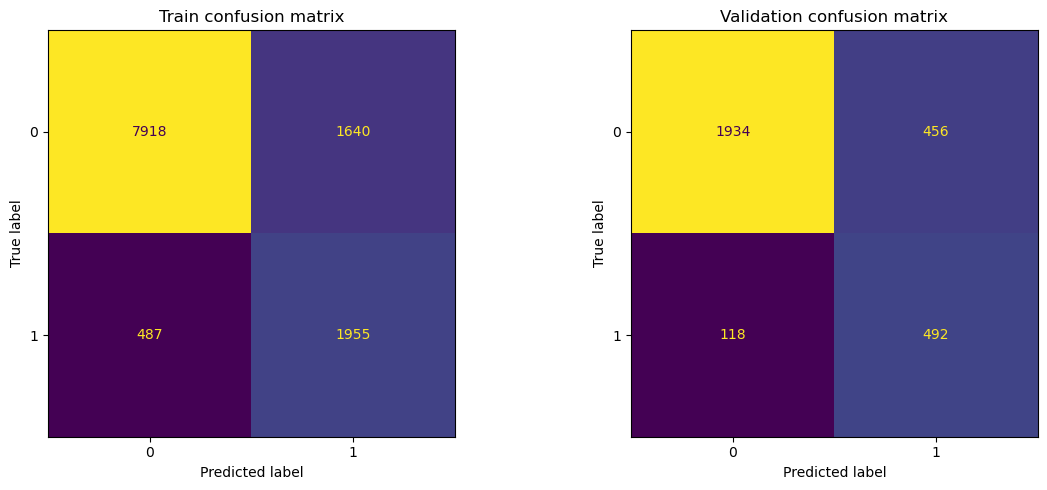

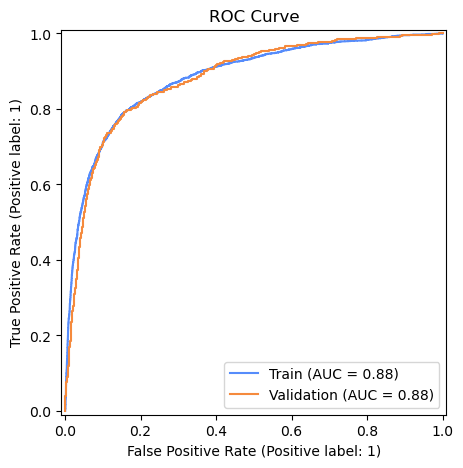

Висновок: модель має 'хороша' якість за ROC AUC оцінкою на validation даних.


In [79]:
train_probs = model.predict_proba(X_train)[:, 1]
val_probs = model.predict_proba(X_val)[:, 1]

train_preds = (train_probs >= 0.5).astype(int)
val_preds = (val_probs >= 0.5).astype(int)

train_auc = roc_auc_score(train_targets, train_probs)
val_auc = roc_auc_score(val_targets, val_probs)

train_f1 = f1_score(train_targets, train_preds)
val_f1 = f1_score(val_targets, val_preds)

print("Train AUROC:", round(train_auc, 4))
print("Validation AUROC:", round(val_auc, 4))
print("Train F1:", round(train_f1, 4))
print("Validation F1:", round(val_f1, 4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix(train_targets, train_preds)
).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Train confusion matrix")

ConfusionMatrixDisplay(
    confusion_matrix(val_targets, val_preds)
).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Validation confusion matrix")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(train_targets, train_probs, name="Train", ax=ax)
RocCurveDisplay.from_predictions(val_targets, val_probs, name="Validation", ax=ax)
ax.set_title("ROC Curve")
plt.show()

if val_auc >= 0.85:
    quality = "хороша"
elif val_auc >= 0.75:
    quality = "задовільна"
else:
    quality = "потребує покращення"

print(f"Висновок: модель має '{quality}' якість за ROC AUC оцінкою на validation даних.")

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [80]:
majority_class = train_targets.mode()[0]

baseline_train_preds = np.full(shape=len(train_targets), fill_value=majority_class)
baseline_val_preds = np.full(shape=len(val_targets), fill_value=majority_class)

baseline_train_accuracy = accuracy_score(train_targets, baseline_train_preds)
baseline_val_accuracy = accuracy_score(val_targets, baseline_val_preds)

model_train_accuracy = accuracy_score(train_targets, train_preds)
model_val_accuracy = accuracy_score(val_targets, val_preds)

print("Majority class:", majority_class)
print("Baseline train accuracy:", round(baseline_train_accuracy, 4))
print("Baseline validation accuracy:", round(baseline_val_accuracy, 4))
print("Logistic regression train accuracy:", round(model_train_accuracy, 4))
print("Logistic regression validation accuracy:", round(model_val_accuracy, 4))

if model_val_accuracy > baseline_val_accuracy and val_auc > 0.75:
    conclusion = "наша модель краща за baseline і має прийнятну/хорошу якість"
elif model_val_accuracy > baseline_val_accuracy:
    conclusion = "наша модель краща за baseline за accuracy, але її варто ще покращувати"
else:
    conclusion = "модель недостатньо хороша, бо не перевершує простий baseline"

print("Висновок:", conclusion)

Majority class: 0.0
Baseline train accuracy: 0.7965
Baseline validation accuracy: 0.7967
Logistic regression train accuracy: 0.8227
Logistic regression validation accuracy: 0.8087
Висновок: наша модель краща за baseline і має прийнятну/хорошу якість


9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [81]:
model_bundle = {
    "model": model,
    "scaler": scaler,
    "encoder": encoder,
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols,
    "encoded_cols": encoded_cols,
    "model_cols": model_cols,
    "numeric_medians": numeric_medians,
    "categorical_modes": categorical_modes,
    "input_cols": input_cols,
    "target_col": target_col
}

model_path = os.path.join(ARTIFACTS_DIR, "log_reg.joblib")
joblib.dump(model_bundle, model_path)

loaded_bundle = joblib.load(model_path)
model_2 = loaded_bundle["model"]

print("Model saved to:", model_path)
print("Model loaded successfully:", type(model_2))

Model saved to: artifacts/log_reg.joblib
Model loaded successfully: <class 'sklearn.linear_model._logistic.LogisticRegression'>


10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [82]:
def predict_raw_df(
    scaler,
    encoder,
    numeric_cols,
    categorical_cols,
    input_df: pd.DataFrame,
    model=model_2,
    numeric_medians=numeric_medians,
    categorical_modes=categorical_modes,
    encoded_cols=encoded_cols,
    model_cols=model_cols
):
    prepared_df = input_df.copy()

    prepared_df[numeric_cols] = prepared_df[numeric_cols].fillna(numeric_medians)

    for col in categorical_cols:
        prepared_df[col] = prepared_df[col].fillna(categorical_modes[col])

    prepared_df[numeric_cols] = scaler.transform(prepared_df[numeric_cols])

    encoded_df = pd.DataFrame(
        encoder.transform(prepared_df[categorical_cols]),
        columns=encoded_cols,
        index=prepared_df.index
    )

    prepared_df = pd.concat(
        [prepared_df[numeric_cols], encoded_df],
        axis=1
    )

    X_input = prepared_df[model_cols]
    prob = model.predict_proba(X_input)[:, 1]

    return prob

In [83]:
predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, raw_df.head())

array([0.0271236 , 0.13786371, 0.7570354 , 0.71403815, 0.99353308])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [84]:
test_raw_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

test_raw_df["Exited"] = predict_raw_df(
    scaler,
    encoder,
    numeric_cols,
    categorical_cols,
    test_raw_df
)

display(test_raw_df.head())

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.230960
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.138355
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.411931
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.467479
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.209672


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [85]:
sample_submission = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

submission_df = sample_submission[["id"]].copy()
submission_df = submission_df.merge(
    test_raw_df[["id", "Exited"]],
    on="id",
    how="left"
)

display(submission_df.head())

submission_path = os.path.join(ARTIFACTS_DIR, "submission_log_reg.csv")
submission_df.to_csv(submission_path, index=False)

print("Submission saved to:", submission_path)
print("Submission shape:", submission_df.shape)
print("Missing predictions:", submission_df["Exited"].isna().sum())

,id,Exited
0,15000,0.230960
1,15001,0.138355
2,15002,0.411931
3,15003,0.467479
4,15004,0.209672


Submission saved to: artifacts/submission_log_reg.csv
Submission shape: (10000, 2)
Missing predictions: 0
